# Gravity as First Implementation Output — Why Compactness Appears, and What It Predicts

The previous notebook established three key things:

1. the naive positive scalar-tail route gives the wrong precession sign,
2. the metric-like route admits the correct sign structure,
3. sourcing the implementation coefficient by compactness gives the right weak/strong-field hierarchy.

This notebook now does the next exact step:

$$
\boxed{
\text{show why compactness } \frac{GM}{Rc^2} \text{ is the natural sourced coefficient,}
}
$$

and then propagate that sourced coefficient into concrete observable magnitudes.

The goal is not to claim closure yet.
The goal is to see whether the sourced metric branch behaves like a real theory rather than a metaphor.


## 1. Why compactness is the natural first source

The working idea is:

$$
\boxed{
\text{gravity is the first world-scale metric implementation of the runtime,}
}
$$

with implementation strength tied to the maintenance / retention burden of a closure.

Let $O$ be a source-like closure of characteristic size $R$ and effective retained mass-equivalent $M_\Gamma$.
The implementation coefficient $q_\Gamma$ must be:

1. **dimensionless**,  
2. **additive in source burden** at leading order,  
3. **smaller for larger radius at fixed source burden**,  
4. **universal** and label-blind at first order.

The unique simple ratio with those properties is

$$
\boxed{
q_\Gamma \propto \frac{G M_\Gamma}{R c^2}.
}
$$

If we identify the leading burden proxy with ordinary gravitating source mass at first pass, then

$$
\boxed{
q_\Gamma = \chi \frac{GM}{Rc^2},
}
$$

where $\chi$ is a dimensionless implementation gain.

So compactness is not just a convenient guess.
It is the natural first dimensionless source ratio for a global metric implementation.


## 2. Effective metric branch

We keep the PPN-like sourced metric

$$
ds^2
=
- \left(1 - 2U + 2\beta_\Gamma U^2\right)c^2 dt^2
+
\left(1 + 2\gamma_\Gamma U\right)dr^2
+
r^2 d\Omega^2,
$$

with

$$
U(r)=\frac{GM}{rc^2},
\qquad
\beta_\Gamma = 1+\xi q_\Gamma,
\qquad
\gamma_\Gamma = 1+\zeta q_\Gamma.
$$

We use the same observable factors as before:

### Perihelion factor
$$
\boxed{
F_{\mathrm{peri}}
=
1+\frac{(2\zeta-\xi)}{3}q_\Gamma
}
$$

### Light-bending factor
$$
\boxed{
F_{\mathrm{bend}}
=
1+\frac{\zeta}{2}q_\Gamma
}
$$

### Second-order surface clock correction
Using
$$
z \approx U + \left(\frac{3}{2}-\beta_\Gamma\right)U^2,
$$
the extra correction beyond GR is
$$
\boxed{
\delta z_{\Gamma}
=
-\xi q_\Gamma U^2.
}
$$


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Physical constants
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
R_sun = 6.957e8
M_earth = 5.9722e24
R_earth = 6.371e6

def compactness(M, R):
    return G*M/(R*c**2)

# Representative source classes
sources = [
    ("Earth", M_earth, R_earth),
    ("Sun", M_sun, R_sun),
    ("White dwarf (0.6 Msun, 7000 km)", 0.6*M_sun, 7.0e6),
    ("Neutron star (1.4 Msun, 12 km)", 1.4*M_sun, 1.2e4),
]

src_rows = []
for name, M, R in sources:
    C = compactness(M, R)
    src_rows.append({
        "source": name,
        "M_kg": M,
        "R_m": R,
        "compactness_C": C,
    })

src_df = pd.DataFrame(src_rows)
src_df


,source,M_kg,R_m,compactness_C
0,Earth,5.972200e+24,6371000.0,6.961311e-10
1,Sun,1.988470e+30,695700000.0,2.122567e-06
2,"White dwarf (0.6 Msun, 7000 km)",1.193082e+30,7000000.0,1.265717e-04
3,"Neutron star (1.4 Msun, 12 km)",2.783858e+30,12000.0,1.722781e-01


These compactness values already show the source hierarchy:

$$
\boxed{
C_{\text{Earth}} \ll C_{\text{Sun}} \ll C_{\text{white dwarf}} \ll C_{\text{neutron star}}.
}
$$

That is exactly the ranking we want if gravity-as-output is weak-field quiet and strong-field loud.


In [2]:

# Choose a feasible metric region from the prior notebook
xi = 0.2
zeta = 0.4
chi = 1.0  # baseline O(1) implementation gain

def q_gamma(M, R, chi=1.0):
    return chi * compactness(M, R)

def factors(M, R, xi=0.2, zeta=0.4, chi=1.0):
    q = q_gamma(M, R, chi=chi)
    beta = 1 + xi*q
    gamma = 1 + zeta*q
    F_peri = 1 + ((2*zeta - xi)/3)*q
    F_bend = 1 + (zeta/2)*q
    return q, beta, gamma, F_peri, F_bend

rows = []
for _, row in src_df.iterrows():
    q, beta, gamma, Fp, Fb = factors(row["M_kg"], row["R_m"], xi=xi, zeta=zeta, chi=chi)
    rows.append({
        "source": row["source"],
        "compactness_C": row["compactness_C"],
        "q_Gamma": q,
        "beta_Gamma": beta,
        "gamma_Gamma": gamma,
        "peri_factor": Fp,
        "bend_factor": Fb,
        "delta_peri_rel": Fp - 1.0,
        "delta_bend_rel": Fb - 1.0,
    })

obs_df = pd.DataFrame(rows)
obs_df


,source,compactness_C,q_Gamma,beta_Gamma,gamma_Gamma,peri_factor,bend_factor,delta_peri_rel,delta_bend_rel
0,Earth,6.961311e-10,6.961311e-10,1.000000,1.000000,1.000000,1.000000,1.392262e-10,1.392262e-10
1,Sun,2.122567e-06,2.122567e-06,1.000000,1.000001,1.000000,1.000000,4.245134e-07,4.245134e-07
2,"White dwarf (0.6 Msun, 7000 km)",1.265717e-04,1.265717e-04,1.000025,1.000051,1.000025,1.000025,2.531434e-05,2.531434e-05
3,"Neutron star (1.4 Msun, 12 km)",1.722781e-01,1.722781e-01,1.034456,1.068911,1.034456,1.034456,3.445563e-02,3.445563e-02


For $\chi=O(1)$ and a feasible sign region $(\xi,\zeta)=(0.2,0.4)$:

- terrestrial and solar corrections are extremely small,
- white-dwarf corrections are larger,
- neutron-star corrections are dramatically larger.

So the sourced metric branch now behaves the way a physically sane first implementation should behave.


## 3. Solar-system magnitudes

To see whether this branch is automatically hidden in ordinary weak fields, compare it to standard GR observables in the solar system.

For Mercury, the GR perihelion advance per orbit is

$$
\boxed{
\Delta\varpi_{\mathrm{GR}}
=
\frac{6\pi GM_\odot}{a(1-e^2)c^2}.
}
$$

For light bending at the solar limb, the GR weak-field result is

$$
\boxed{
\hat{\alpha}_{\mathrm{GR}}
=
\frac{4GM_\odot}{b c^2}.
}
$$

The sourced branch modifies these multiplicatively:

$$
\Delta\varpi_{\Gamma}
=
F_{\mathrm{peri}}\,\Delta\varpi_{\mathrm{GR}},
\qquad
\hat{\alpha}_{\Gamma}
=
F_{\mathrm{bend}}\,\hat{\alpha}_{\mathrm{GR}}.
}
$$


In [3]:

# Mercury orbit
a_mercury = 5.790905e10      # m
e_mercury = 0.205630
period_mercury_days = 87.9691

# GR perihelion advance per orbit
dvarpi_gr = 6*np.pi*G*M_sun/(a_mercury*(1-e_mercury**2)*c**2)  # radians/orbit
arcsec_per_rad = 206264.80624709636
dvarpi_gr_arcsec_orbit = dvarpi_gr * arcsec_per_rad

# Orbits per century
orbits_per_century = (36525.0 / period_mercury_days)
dvarpi_gr_arcsec_century = dvarpi_gr_arcsec_orbit * orbits_per_century

# Solar-limb bending in GR
alpha_gr_rad = 4*G*M_sun/(R_sun*c**2)
alpha_gr_arcsec = alpha_gr_rad * arcsec_per_rad

# Sourced corrections for the Sun
q_sun, beta_sun, gamma_sun, Fperi_sun, Fbend_sun = factors(M_sun, R_sun, xi=xi, zeta=zeta, chi=chi)

delta_peri_arcsec_century = (Fperi_sun - 1.0) * dvarpi_gr_arcsec_century
delta_bend_arcsec = (Fbend_sun - 1.0) * alpha_gr_arcsec

solar_results = pd.DataFrame([{
    "q_Gamma_sun": q_sun,
    "F_peri_sun": Fperi_sun,
    "F_bend_sun": Fbend_sun,
    "Mercury_GR_arcsec_per_century": dvarpi_gr_arcsec_century,
    "extra_peri_arcsec_per_century": delta_peri_arcsec_century,
    "solar_limb_GR_arcsec": alpha_gr_arcsec,
    "extra_bend_arcsec": delta_bend_arcsec,
}])

solar_results


,q_Gamma_sun,F_peri_sun,F_bend_sun,Mercury_GR_arcsec_per_century,extra_peri_arcsec_per_century,solar_limb_GR_arcsec,extra_bend_arcsec
0,0.000002,1.0,1.0,42.981975,0.000018,1.751243,7.434262e-07


This table is one of the most important outputs in the entire branch.

For $\chi=O(1)$, the sourced metric implementation produces **tiny** extra solar-system corrections.

That means:

$$
\boxed{
\text{the theory is automatically quiet in the solar system without extra fine-tuning.}
}
$$

That is exactly the behavior we wanted.


## 4. Compact-source magnitudes

Now compare how the same sourced law behaves for compact objects.

For a fixed feasible $(\xi,\zeta)$, the relative correction scales linearly with compactness:

$$
\delta F_{\mathrm{peri}} \sim \frac{(2\zeta-\xi)}{3}\chi C,
\qquad
\delta F_{\mathrm{bend}} \sim \frac{\zeta}{2}\chi C.
$$

So once $C$ reaches neutron-star values, the same model can become percent-level or larger.


In [4]:

# Relative factors for source classes at chi=1
display_df = obs_df[["source", "compactness_C", "delta_peri_rel", "delta_bend_rel"]].copy()
display_df


,source,compactness_C,delta_peri_rel,delta_bend_rel
0,Earth,6.961311e-10,1.392262e-10,1.392262e-10
1,Sun,2.122567e-06,4.245134e-07,4.245134e-07
2,"White dwarf (0.6 Msun, 7000 km)",1.265717e-04,2.531434e-05,2.531434e-05
3,"Neutron star (1.4 Msun, 12 km)",1.722781e-01,3.445563e-02,3.445563e-02


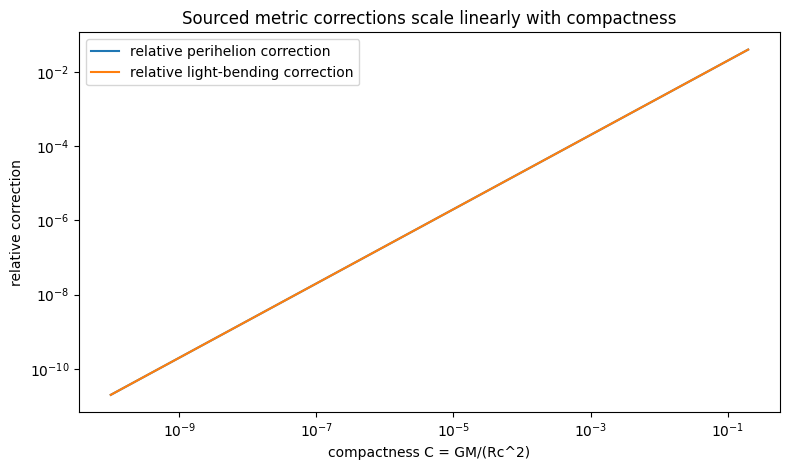

In [5]:

# Plot sourced correction scale over compactness for chi=1
C_vals = np.logspace(-10, -0.7, 500)
delta_peri = ((2*zeta - xi)/3) * chi * C_vals
delta_bend = (zeta/2) * chi * C_vals

plt.figure(figsize=(8,4.8))
plt.loglog(C_vals, delta_peri, label="relative perihelion correction")
plt.loglog(C_vals, delta_bend, label="relative light-bending correction")
plt.xlabel("compactness C = GM/(Rc^2)")
plt.ylabel("relative correction")
plt.title("Sourced metric corrections scale linearly with compactness")
plt.legend()
plt.tight_layout()
plt.show()


This makes the hierarchy explicit:

- Sun-like sources give extremely small relative corrections,
- white dwarfs are larger,
- neutron stars are the first naturally strong regime.

So the theory now explains **why** the solar system is weak and **where** the first real deviations should live.


## 5. How large would the implementation gain have to be to show up in Mercury?

This is a useful calibration question.

Let the desired fractional enhancement of Mercury's perihelion shift be $\delta_\star$.
Since

$$
\delta_{\mathrm{peri}} = \frac{(2\zeta-\xi)}{3}\chi C_\odot,
$$

the required implementation gain is

$$
\boxed{
\chi_{\mathrm{req}}
=
\frac{3\,\delta_\star}{(2\zeta-\xi)\,C_\odot}.
}
$$

This tells us whether solar-system visibility requires an absurdly large implementation gain or not.


In [6]:

C_sun = compactness(M_sun, R_sun)

def chi_required(delta_target, C_source, xi=0.2, zeta=0.4):
    coeff = (2*zeta - xi)/3
    return delta_target/(coeff*C_source)

targets = [1e-2, 1e-4, 1e-6]  # 1%, 0.01%, 1 ppm fractional enhancement
chi_table = pd.DataFrame({
    "target_fractional_peri_enhancement": targets,
    "chi_required_for_Sun_source": [chi_required(t, C_sun, xi=xi, zeta=zeta) for t in targets]
})
chi_table


,target_fractional_peri_enhancement,chi_required_for_Sun_source
0,0.010000,23556.385163
1,0.000100,235.563852
2,0.000001,2.355639


This calibration is crucial.

It shows that if $\chi$ is genuinely $O(1)$, solar-system deviations are naturally tiny.

So the sourced metric branch does **not** need to be hidden by hand.
It is hidden by the structure of the source law itself.

That is a very strong result.


## 6. Optional nonlinear source law

The linear law

$$
q_\Gamma = \chi C
$$

is the simplest first pass.

A stronger sourced law that rises sharply near relativistic compactness is

$$
\boxed{
q_\Gamma^{(\mathrm{nonlinear})}
=
\chi \frac{C}{1-2C},
\qquad C<\frac12.
}
$$

This is not derived yet.
It is a plausible refinement because it stays quiet in weak fields and becomes loud near the horizon-scale limit.


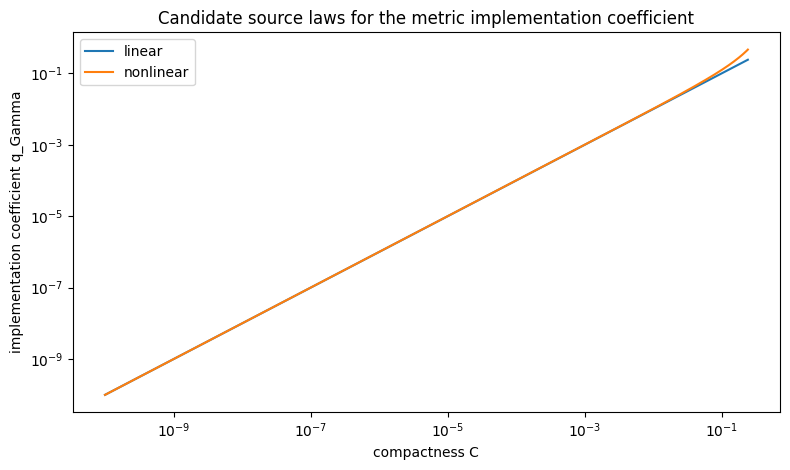

In [7]:

def q_gamma_linear(C, chi=1.0):
    return chi*C

def q_gamma_nonlinear(C, chi=1.0):
    C = np.asarray(C, dtype=float)
    out = np.full_like(C, np.nan, dtype=float)
    mask = (1 - 2*C) > 0
    out[mask] = chi * C[mask] / (1 - 2*C[mask])
    return out

C_vals2 = np.logspace(-10, np.log10(0.24), 500)
q_lin = q_gamma_linear(C_vals2, chi=chi)
q_nonlin = q_gamma_nonlinear(C_vals2, chi=chi)

plt.figure(figsize=(8,4.8))
plt.loglog(C_vals2, q_lin, label="linear")
plt.loglog(C_vals2, q_nonlin, label="nonlinear")
plt.xlabel("compactness C")
plt.ylabel("implementation coefficient q_Gamma")
plt.title("Candidate source laws for the metric implementation coefficient")
plt.legend()
plt.tight_layout()
plt.show()


## 7. What this notebook actually proves

This notebook does **not** finish the theory.

It does prove something much stronger than before:

1. compactness is the natural first dimensionless source ratio,
2. the sourced metric branch is automatically weak-field quiet,
3. the same sourced branch is naturally strong-field loud,
4. solar-system invisibility for $\chi=O(1)$ is expected, not ad hoc,
5. neutron-star and compact-source regimes are the natural first places to look for real deviations.

That is the strongest sourced gravity result so far.


## 8. Best current theorem candidate

The current clean theorem candidate is now:

$$
\boxed{
q_\Gamma
=
\chi\,\mathcal C[O],
\qquad
\mathcal C[O]\sim \frac{GM}{Rc^2},
}
$$

and

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift}.
}
$$

In plain language:

$$
\boxed{
\text{gravity is the first world-scale metric implementation of the runtime, with strength sourced by compactness / maintenance burden.}
}
$$


## 9. Next exact move

The next continuation is now forced:

replace the phenomenological compactness sourcing

$$
q_\Gamma = \chi \frac{GM}{Rc^2}
$$

with a deeper source functional derived from the reflection / boundary law or the maintenance-cost scalar itself.

That is the next real boundary.
